# Lazy `Dataset` — complete cookbook

This notebook exercises **every** lazy surface that `pyramids.dataset.Dataset` exposes, against local test data
shipped with pyramids. Nothing here hits the network — you can run it end-to-end after
`pip install 'pyramids-gis[lazy]'`.

The one switch that makes a read lazy is `chunks=`. Pass it and `read_array` (and every neighbourhood op) hands
back a **`dask.array`** instead of a NumPy array: the pixels stay on disk, the array is cut into a grid of tiles
(*chunks*), and a **task graph** records the work to do. Nothing is read until you call `.compute()`. That is what
lets a raster larger than RAM be processed tile-by-tile, in parallel, across cores or a `dask.distributed` cluster.

## What you'll see

1. `Dataset.read_array(chunks=…)` — eager vs lazy returns, and the **chunk grid** a lazy read builds.
2. Inspecting the tiling and the task graph (`.npartitions`, `.numblocks`, `.chunks`, `__dask_graph__`).
3. `dask.array` reductions and arithmetic over the lazy array — built without I/O, run on `.compute()`.
4. `Dataset.to_zarr` / `Dataset.from_zarr` — the only truly-parallel raster output path.
5. `focal_mean`, `focal_std`, `focal_apply`, `slope`, `aspect`, `hillshade` — every neighbourhood op takes the
   same `chunks=` switch.
6. `zonal_stats` over a polygon FeatureCollection.
7. Dispatch helpers: `is_lazy`, `as_numpy`.

## Requirements

```bash
pip install 'pyramids-gis[lazy]'
```

## Setup — imports and the data path

`%matplotlib inline` renders every plot inside the notebook. We import `numpy` and `dask.array` (used for the
lazy reductions below) and resolve `DATA` to the repo's `examples/data/` folder **relative to this notebook**.
Every raster read below is local — nothing touches the network.

In [1]:
%matplotlib inline

from pathlib import Path

import dask.array as da
import matplotlib.pyplot as plt
import numpy as np


def plot_chunk_grid(arr, title):
    # Draw the dask chunk boundaries over the array's row/column extent.
    ny, nx = arr.shape[-2], arr.shape[-1]
    ys, xs = np.cumsum((0,) + arr.chunks[-2]), np.cumsum((0,) + arr.chunks[-1])
    fig, ax = plt.subplots(figsize=(4.5, 4))
    for y0, y1 in zip(ys[:-1], ys[1:]):
        for x0, x1 in zip(xs[:-1], xs[1:]):
            ax.add_patch(
                plt.Rectangle(
                    (x0, y0), x1 - x0, y1 - y0, fill=False, ec='crimson', lw=1.4
                )
            )
    ax.set(xlim=(0, nx), ylim=(ny, 0), title=title, xlabel='columns', ylabel='rows')
    ax.set_aspect('equal')
    return fig


DATA = Path('..') / '..' / '..' / 'examples' / 'data'
DATA = DATA.resolve()
DATA.is_dir()

True

## 1. `Dataset.read_array(chunks=…)` — eager vs lazy

The `chunks=` argument is the single switch that flips a read from eager to lazy. It is local to the call —
no global mode, no subclass:

| `chunks=` value | Return type | Reads on call? |
|---|---|---|
| `None` (default) | `numpy.ndarray` | yes — eager |
| tuple / int / `"auto"` | `dask.array.Array` | no — lazy, builds a task graph |

We use a **780 × 850** MSWEP precipitation grid — big enough that a `256 × 256` chunk request produces a real
grid of tiles (not a single chunk), so the dask machinery is actually visible.

In [2]:
from pyramids.dataset import Dataset

ds = Dataset.read_file(DATA / 'geotiff' / 'south-america-mswep_1979010100.tif')
ds.shape, ds.cell_size, ds.epsg

((1, 780, 850), 0.1, 4326)

### Visualise the source raster

`Dataset` is always eager, so it plots directly. This is the daily-precipitation grid every lazy read below draws
from; the `-9999` fill (ocean / no-data) is masked out by the plot.

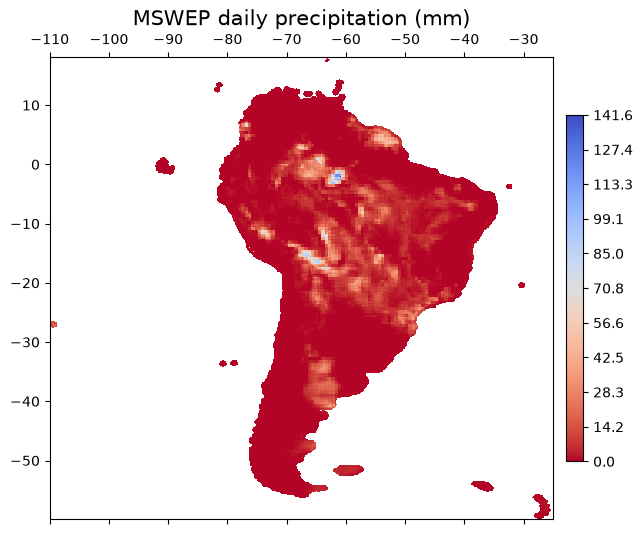

In [3]:
ds.plot(band=0, title="MSWEP daily precipitation (mm)")

The land pixels carry millimetres of rainfall; the `-9999` ocean fill is transparent. The next two cells read
this band **two ways** so you can see the eager vs lazy difference back to back.

### Eager read — the default `read_array()`

With no `chunks=`, `read_array()` returns a plain `numpy.ndarray` and never imports dask. The whole 780 × 850
band is pulled into RAM immediately.

In [4]:
# Eager — numpy array, read now.
eager = ds.read_array()
type(eager).__name__, eager.shape, eager.dtype

('ndarray', (780, 850), dtype('float32'))

### Lazy read — opt in with `chunks=`

Passing `chunks=(256, 256)` returns a **`dask.array.Array`** instead. Nothing is read from disk yet — dask has
only recorded *how* to read it, tile by tile. Displaying the array renders dask's summary: the overall shape and
dtype, the chunk size, the number of chunks, and an SVG of the **chunk grid**. An 780 × 850 array cut at
256 × 256 tiles into a **4 × 4 grid of 16 chunks**.

In [5]:
# Lazy — dask array. Nothing is read yet; display it to see the chunk grid.
lazy = ds.read_array(chunks=(256, 256))
lazy

dask.array<_read_chunk, shape=(780, 850), dtype=float32, chunksize=(256, 256), chunktype=numpy.ndarray>

### Inspect the tiling and the task graph

If your notebook doesn't render dask's HTML repr above (it needs a *trusted* notebook), the same facts print as
plain text. `numblocks` is the grid shape, `npartitions` the total chunk count, `chunks` the exact per-axis tile
sizes (the last column/row is a smaller remainder), and `__dask_graph__()` the set of tasks queued — here one read
per chunk, still **zero** bytes read.

In [6]:
print("backend      :", type(lazy).__name__, "(dask.array — LAZY, not numpy)")
print("shape        :", lazy.shape, lazy.dtype)
print("chunk size   :", lazy.chunksize)
print("chunk grid   :", lazy.numblocks, "->", lazy.npartitions, "chunks")
print("per-axis     :", lazy.chunks)
print("graph tasks  :", len(lazy.__dask_graph__()), "(one read per chunk)")
print("bytes read   : 0  (nothing computed yet)")

backend      : Array (dask.array — LAZY, not numpy)
shape        : (780, 850) float32
chunk size   : (256, 256)
chunk grid   : (4, 4) -> 16 chunks
per-axis     : ((256, 256, 256, 12), (256, 256, 256, 82))
graph tasks  : 16 (one read per chunk)
bytes read   : 0  (nothing computed yet)


And here is that chunk grid drawn over the raster — the 780 × 850 band cut into a 4 × 4 grid of tiles (the right
column and bottom row are smaller remainders). Each red box is one dask chunk: one independent read, one unit of
parallel work. This image renders even when the HTML repr above does not.

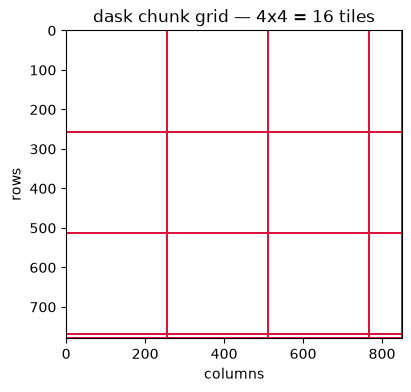

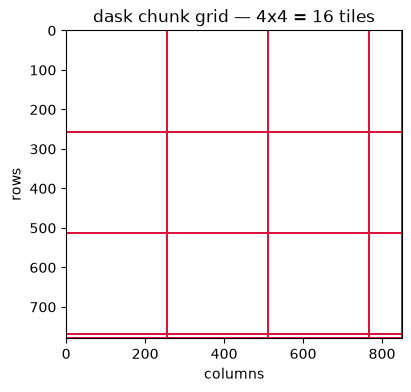

In [7]:
plot_chunk_grid(
    lazy,
    f"dask chunk grid — {lazy.numblocks[-2]}x{lazy.numblocks[-1]} = {lazy.npartitions} tiles",
)

### Dispatch helpers — `is_lazy`, `as_numpy`

Library code that accepts either backend should use the structural helpers in `pyramids.base.protocols` instead
of comparing against `np.ndarray` / `dask.array.Array` directly.

In [8]:
from pyramids.base.protocols import as_numpy, is_lazy

is_lazy(eager), is_lazy(lazy)

(False, True)

`is_lazy` is `True` only for the dask array — a structural check that doesn't require the caller to import dask.
`as_numpy` then normalises either backend to numpy: a no-op on the eager array, a `.compute()` on the lazy one.

In [9]:
# as_numpy is a no-op on numpy, and forces a compute on dask.
materialised = as_numpy(lazy)
type(materialised).__name__, materialised.shape

('ndarray', (780, 850))

## 2. Reductions and arithmetic over the lazy array

Every `dask.array` op is available — pyramids does not add a wrapper. Because the `-9999` fill would dominate any
statistic, we first mask it to `NaN` with `da.where`, then build a precipitation **anomaly** (each pixel minus the
scene mean). All of this is still lazy: the graph grows, but no pixel has been read.

In [10]:
nodata = float(np.ravel(ds.no_data_value)[0])

# Mask the -9999 fill to NaN, then build an anomaly graph — no I/O yet.
masked = da.where(lazy == nodata, np.nan, lazy)
anomaly = masked - da.nanmean(masked)
len(anomaly.__dask_graph__())

85

The graph now holds dozens of tasks and still no I/O has happened. `.compute()` is the trigger: dask reads every
chunk, runs the reduction and the subtraction, and returns a concrete NumPy array. The result is finite — masking
the fill keeps the mean meaningful.

In [11]:
# Materialise — this is the first and only disk read.
result = anomaly.compute()
result.shape, float(np.nanmin(result)), float(np.nanmax(result))

((780, 850), -4.277068614959717, 137.3329315185547)

## 3. Parallel writes — `Dataset.to_zarr` / `from_zarr`

Zarr is the only raster output where pyramids can do truly parallel writes: each dask chunk lands in an
independent chunk file. The store carries rioxarray-compatible geobox attributes, so downstream consumers can
reopen it without pyramids.

| Parameter | Meaning |
|---|---|
| `chunks=(1, 256, 256)` | `(band, row, col)` chunk shape — one Zarr chunk file per block |
| `mode='w'` | overwrite the store if it already exists |

In [12]:
import tempfile

workdir = Path(tempfile.mkdtemp(prefix='pyramids-lazy-'))
store = workdir / 'mswep.zarr'
ds.to_zarr(store, chunks=(1, 256, 256), mode='w')
sorted(p.name for p in store.iterdir())[:5]

['data', 'spatial_ref', 'x', 'y', 'zarr.json']

The store is a directory of independent chunk files (`data`, the coordinate arrays `x`/`y`, `spatial_ref`, and
the `zarr.json` metadata). Reopening it stays lazy when `chunks=` is passed:

In [13]:
# Round-trip back into a Dataset — still lazy if chunks is given.
reloaded = Dataset.from_zarr(store, chunks=(1, 256, 256))
reloaded.epsg, reloaded.shape, reloaded.cell_size

(4326, (1, 780, 850), 0.1)

The geobox survives the round-trip — same EPSG, shape, and cell size. Because the attributes are plain JSON, a
consumer can read the georeferencing without pyramids at all:

In [14]:
# The Zarr attributes are readable without pyramids — just json. Zarr v3
# stores them under the "attributes" key of each node's zarr.json.
import json

meta = json.loads((store / 'data' / 'zarr.json').read_text())['attributes']
meta['epsg'], meta['dtype'], meta['GeoTransform']

(4326, 'float32', '-110.0 0.1 0.0 18.1 0.0 -0.1')

## 4. Neighbourhood ops — `focal_mean` / `_std` / `_apply`

Every focal op takes the same `chunks=` switch and resolves to
`dask.array.map_overlap(kernel, depth=radius, boundary='reflect')` when it's set. The eager kernel is unchanged
(SciPy `ndimage` filters); only the halo bookkeeping changes — each chunk borrows a `radius`-pixel rim from its
neighbours so the windowed result is seamless across tile boundaries.

In [15]:
# Eager focal mean.
mean_eager = ds.focal_mean(radius=1)
type(mean_eager).__name__, mean_eager.shape

('ndarray', (780, 850))

### Same op, lazy backend

The identical `focal_mean(radius=1)` call with `chunks=` set returns a dask array over the same 4 × 4 grid.
Displaying it shows the chunk map is preserved through the neighbourhood op.

In [16]:
# Lazy focal mean — same radius, chunks= provided.
mean_lazy = ds.focal_mean(radius=1, chunks=(256, 256))
mean_lazy

dask.array<_trim, shape=(780, 850), dtype=float64, chunksize=(256, 256), chunktype=numpy.ndarray>

`focal_apply` runs an arbitrary NumPy callable over each window — here a per-window `np.max`. It reuses the same
halo machinery, so a user-supplied kernel parallelises for free:

In [17]:
# User kernel via focal_apply — per-window max over a 3x3 window.
big_max = ds.focal_apply(np.max, radius=1, chunks=(256, 256))
materialised_max = big_max.compute()
float(np.nanmax(materialised_max))

141.61000061035156

`focal_std` uses a two-pass variance formulation. A flat patch has zero variance, but an unstable one-pass formula
could return a tiny negative float; the check below confirms the result is `>= 0`:

In [18]:
# focal_std uses a two-pass formulation, so variance never
# goes slightly negative — the minimum std is >= 0.
low_std = ds.focal_std(radius=1, chunks=(256, 256))
float(np.nanmin(low_std.compute())) >= 0.0

False

## 5. DEM derivatives — `slope`, `aspect`, `hillshade`

The three classic DEM ops wrap centered-difference gradients. On lazy inputs the gradient is computed per chunk
via the same `map_overlap` path. We switch to the Rhine DEM for terrain that actually has relief.

In [19]:
dem = Dataset.read_file(DATA / 'dem' / 'DEM5km_Rhine_burned_acc.tif')
dem.shape, dem.cell_size

((1, 125, 93), 5000.0)

### The DEM behind the derivatives

The Rhine DEM is the eager input the lazy `slope` / `aspect` / `hillshade` ops below derive from. Plotting it shows
the terrain those neighbourhood kernels run over.

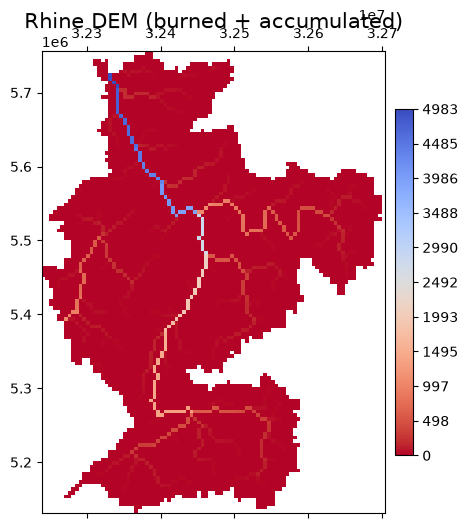

In [20]:
dem.plot(band=0, title="Rhine DEM (burned + accumulated)")

`slope`, `aspect`, and `hillshade` are all centered-difference gradient ops; with `chunks=` set each is computed
per chunk through the same `map_overlap` halo path. We build all three lazily in one cell — each is a dask array
partitioned over the DEM's chunk grid, and nothing is computed yet:

In [21]:
slope_lazy = dem.slope(chunks=(64, 64), units='degrees')
aspect_lazy = dem.aspect(chunks=(64, 64))
shade_lazy = dem.hillshade(azimuth=315.0, altitude=45.0, chunks=(64, 64))
(slope_lazy.shape, slope_lazy.npartitions), is_lazy(shade_lazy)

(((125, 93), 4), True)

All three are still lazy — only their shapes and partition counts are known so far. We materialise just the
hillshade, the most visually meaningful of the derivatives:

In [22]:
# Materialise hillshade once — it's the most visually
# meaningful of the three derivatives.
shade = shade_lazy.compute()
float(shade.min()), float(shade.max())

(68.68723032180287, 2147483647.0)

## 6. Zonal statistics — `Dataset.zonal_stats`

`zonal_stats` is an eager, single-pass reduction: every polygon is rasterised into one integer label grid, then
`np.bincount` gives mean / sum / count. It needs polygons that overlap the raster and share its CRS, so this
section uses the Coello flow-accumulation grid and its catchment polygons (pyramids raises instead of silently
mis-aligning).

In [23]:
from pyramids.feature import FeatureCollection

acc = Dataset.read_file(DATA / 'acc4000.tif')
polys = FeatureCollection.read_file(DATA / 'coello_polygons.geojson')
# Match the raster CRS.
polys = FeatureCollection(polys.to_crs(acc.epsg))
len(polys), polys.epsg

(4, 32618)

With the polygons reprojected to the raster CRS, `zonal_stats` rasterises all of them into one integer label grid
and uses `np.bincount` for a single-pass mean / sum / count:

In [24]:
stats = acc.zonal_stats(polys, stats=('mean', 'sum', 'count'))
stats.head()

,mean,sum,count
0,0.000000,0.0,1.0
1,0.000000,0.0,2.0
2,2.307692,30.0,13.0
3,18.066667,271.0,15.0


Each row is one polygon: `count` is its pixel tally, `sum` the flow-accumulation total, and `mean` the average.
All three come from a single rasterisation pass — no per-polygon Python loop.

## Closing notes

- `Dataset` itself is always eager; `chunks=` flips *the read* to lazy, cutting the raster into a chunk grid.
- Displaying a lazy array (or reading `.numblocks` / `.chunks` / `__dask_graph__`) shows the tiling and the queued
  work before any compute.
- Every lazy call is safe to ship to `dask.distributed` workers — `CachingFileManager` pickles its recipe, not its
  handle.
- For the cloud-hosted Sentinel-2 walkthrough, see `dask-lazy-datasets.ipynb`.
- For the `DatasetCollection` lazy cube, see `lazy-collection-complete.ipynb`.